# RNN do zero: geração de texto caractere a caractere

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flavioluizseixas/aprendizado-de-maquina-para-saude/blob/main/notebooks/RNN/rnn_do_zero_d2l.ipynb)

Implementação didática em **PyTorch**, baseada na seção
[8.5 — Implementação de Redes Neurais Recorrentes do Zero](https://pt.d2l.ai/chapter_recurrent-neural-networks/rnn-scratch.html)
do livro *Dive into Deep Learning* (D2L), de Aston Zhang, Zachary C. Lipton,
Mu Li e Alexander J. Smola.

A rede aprende a prever o próximo caractere de *The Time Machine*, de H. G. Wells.
Implementamos os pesos, a recorrência, o estado oculto, o recorte de gradientes
e o SGD. O PyTorch fornece operações com tensores, entropia cruzada e
diferenciação automática; a retropropagação não é derivada manualmente.
Não usamos `nn.RNN`, `nn.Linear` nem o pacote `d2l`.

**Como executar:** abra no Jupyter, VS Code ou Google Colab, instale as
dependências se necessário e execute as células em ordem. O primeiro acesso
baixa o corpus para `data/timemachine.txt`; depois ele fica disponível localmente.
O perfil `rapido` permite experimentar. Para usar os hiperparâmetros do capítulo,
troque para `livro` e reinicie a execução de todas as células.

Esta adaptação inclui as funções auxiliares de dados, comentários em português,
dois perfis de treinamento e uma comparação de amostragem com modelos novos.
O material adaptado deste notebook é disponibilizado sob
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/), conforme a
[licença do D2L](https://github.com/d2l-ai/d2l-en/blob/master/LICENSE).


## 1. Dependências e configuração

São necessários Python 3.9 ou superior, PyTorch e Matplotlib. Se os imports
falharem, descomente e execute a instalação abaixo no kernel do notebook.


In [17]:
# Descomente na primeira execução se as bibliotecas ainda não estiverem instaladas.
# %pip install torch matplotlib


In [18]:
import hashlib
import math
import random
import re
import time
from collections import Counter
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F


def fixar_semente(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
PERFIL = "livro"  # "rapido" ou "livro"
PERFIS = {
    "rapido": {"num_hiddens": 128, "num_epochs": 50},
    "livro": {"num_hiddens": 512, "num_epochs": 500},
}
config = PERFIS[PERFIL]
batch_size = 32
num_steps = 35
max_tokens = 10_000
num_hiddens = config["num_hiddens"]
num_epochs = config["num_epochs"]
lr = 1.0
clip_theta = 1.0
TREINAR_ALEATORIO = True

# CPU funciona em qualquer plataforma; CUDA é usada quando disponível.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Matrizes pequenas podem ser mais rápidas com apenas uma thread de CPU.
torch.set_num_threads(1)
fixar_semente(SEED)

print(f"PyTorch {torch.__version__} | dispositivo: {device}")
print(f"Perfil: {PERFIL} | unidades ocultas: {num_hiddens} | épocas: {num_epochs}")


PyTorch 2.6.0 | dispositivo: cpu
Perfil: livro | unidades ocultas: 512 | épocas: 500


## 2. Corpus e vocabulário

O pré-processamento segue a [seção 8.2 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/text-preprocessing.html):
mantemos letras e espaços, convertemos para minúsculas e concatenamos as linhas
sem inserir separadores extras. Assim, algumas palavras no limite entre linhas
ficam unidas, como nos dados do capítulo.

O vocabulário é construído antes de limitar o corpus a 10.000 caracteres.
O índice zero representa `<unk>`, reservado para caracteres desconhecidos.
Os dados estão em inglês; por isso, os textos gerados também estarão.


In [19]:
DATA_URL = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
DATA_SHA1 = "090b5e7e70c295757f55df93cb0a180b9691891a"
DATA_PATH = Path("data/timemachine.txt")


def ler_time_machine(path=DATA_PATH):
    path = Path(path)
    if not path.exists():
        try:
            with urlopen(DATA_URL, timeout=60) as response:
                data = response.read()
        except (URLError, TimeoutError) as error:
            raise RuntimeError(
                f"Não foi possível baixar o corpus. Baixe {DATA_URL} "
                f"manualmente, salve em {path.resolve()} e execute novamente."
            ) from error
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError("O corpus baixado não corresponde ao arquivo do D2L.")
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(data)
    else:
        data = path.read_bytes()
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError(f"Checksum incorreto: substitua {path} pelo corpus do D2L.")

    return [
        re.sub(r"[^A-Za-z]+", " ", line).strip().lower()
        for line in data.decode("utf-8").splitlines()
    ]


class Vocab:
    def __init__(self, text):
        self.idx_to_token = ["<unk>"] + [
            token for token, count in Counter(text).most_common()
        ]
        self.token_to_idx = {
            token: index for index, token in enumerate(self.idx_to_token)
        }

    def __len__(self):
        return len(self.idx_to_token)

    def encode(self, text):
        return [self.token_to_idx.get(char, 0) for char in text]

    def decode(self, indices):
        return "".join(self.idx_to_token[int(index)] for index in indices)


lines = ler_time_machine()
text = "".join(lines)
vocab = Vocab(text)
corpus = vocab.encode(text)[:max_tokens]
print(f"Linhas: {len(lines):,} | caracteres usados: {len(corpus):,}")
print(f"Tamanho do vocabulário: {len(vocab)}")
print("Tokens:", vocab.idx_to_token)
print("Trecho:", vocab.decode(corpus[:100]))


Linhas: 3,221 | caracteres usados: 10,000
Tamanho do vocabulário: 28
Tokens: ['<unk>', ' ', 'e', 't', 'a', 'i', 'n', 'o', 's', 'h', 'r', 'd', 'l', 'm', 'u', 'c', 'f', 'w', 'g', 'y', 'p', 'b', 'v', 'k', 'x', 'z', 'j', 'q']
Trecho: the time machine by h g wellsithe time traveller for so it will be convenient to speak of himwas exp


## 3. Minibatches sequenciais e aleatórios

Cada entrada `X` contém índices de caracteres. O alvo `Y` contém os caracteres
seguintes: para `X = "time"`, teríamos `Y = "ime "`.

Na **amostragem sequencial**, uma linha do próximo lote continua a mesma linha
do lote anterior. Na **amostragem aleatória**, embaralhamos subsequências inteiras;
a ordem dos caracteres dentro de cada subsequência é preservada. Os dois
iteradores são recriados a cada época, com um novo deslocamento inicial.
Esse procedimento é apresentado na [seção 8.3 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/language-models-and-dataset.html).


In [20]:
def seq_data_iter_sequential(corpus, batch_size, num_steps, rng):
    offset = rng.randint(0, num_steps)
    usable = ((len(corpus) - offset - 1) // batch_size) * batch_size
    if usable < batch_size * num_steps:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    inputs = torch.tensor(corpus[offset:offset + usable], dtype=torch.long)
    targets = torch.tensor(corpus[offset + 1:offset + usable + 1], dtype=torch.long)
    inputs = inputs.reshape(batch_size, -1)
    targets = targets.reshape(batch_size, -1)
    for start in range(0, inputs.shape[1] - num_steps + 1, num_steps):
        yield inputs[:, start:start + num_steps], targets[:, start:start + num_steps]


def seq_data_iter_random(corpus, batch_size, num_steps, rng):
    offset = rng.randrange(num_steps)
    subsequences = (len(corpus) - offset - 1) // num_steps
    starts = [offset + i * num_steps for i in range(subsequences)]
    if len(starts) < batch_size:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    rng.shuffle(starts)
    for first in range(0, len(starts) - batch_size + 1, batch_size):
        batch_starts = starts[first:first + batch_size]
        inputs = [corpus[start:start + num_steps] for start in batch_starts]
        targets = [corpus[start + 1:start + num_steps + 1] for start in batch_starts]
        yield torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)


class SeqDataLoader:
    def __init__(self, corpus, batch_size, num_steps, use_random_iter=False, seed=42):
        if batch_size < 1 or num_steps < 1:
            raise ValueError("batch_size e num_steps devem ser positivos.")
        self.corpus = corpus
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.use_random_iter = use_random_iter
        self.rng = random.Random(seed)

    def __iter__(self):
        iterator = seq_data_iter_random if self.use_random_iter else seq_data_iter_sequential
        return iterator(self.corpus, self.batch_size, self.num_steps, self.rng)


demo_loader = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
X, Y = next(iter(demo_loader))
assert torch.equal(X[:, 1:], Y[:, :-1])
print("Dimensões de X e Y:", tuple(X.shape), tuple(Y.shape))
print("X[0]:", repr(vocab.decode(X[0])))
print("Y[0]:", repr(vocab.decode(Y[0])))


Dimensões de X e Y: (32, 35) (32, 35)
X[0]: 'e machine by h g wellsithe time tra'
Y[0]: ' machine by h g wellsithe time trav'


## 4. Codificação one-hot

Se o vocabulário tem $V$ tokens, cada índice vira um vetor de tamanho $V$ com
um único valor 1. Transpomos o lote para percorrer primeiro o tempo:

| Tensor | Dimensões |
|---|---|
| Índices `X` | `(batch_size, num_steps)` |
| Entrada one-hot | `(num_steps, batch_size, vocab_size)` |
| Estado oculto | `(batch_size, num_hiddens)` |
| Logits de todos os passos | `(num_steps * batch_size, vocab_size)` |


In [21]:
print("Exemplo com três tokens:")
print(F.one_hot(torch.tensor([0, 2]), num_classes=3))
X_one_hot = F.one_hot(X.T, num_classes=len(vocab)).to(torch.float32)
assert X_one_hot.shape == (num_steps, batch_size, len(vocab))
assert torch.all(X_one_hot.sum(dim=-1) == 1)
print("Dimensões após one-hot:", tuple(X_one_hot.shape))


Exemplo com três tokens:
tensor([[1, 0, 0],
        [0, 0, 1]])
Dimensões após one-hot: (35, 32, 28)


## 5. Pesos, estado oculto e recorrência

Para cada instante $t$, calculamos:

$$H_t = \tanh(X_t W_{xh} + H_{t-1} W_{hh} + b_h)$$
$$O_t = H_t W_{hq} + b_q$$

Os mesmos cinco tensores de parâmetros são usados em todos os passos.
Inicializamos as matrizes com ruído normal de desvio padrão 0,01 e os vieses
com zero. O estado inicial também é zero. `O_t` contém **logits**: valores
anteriores ao softmax, apropriados para a entropia cruzada do PyTorch.


In [22]:
def get_params(vocab_size, num_hiddens, device):
    shapes = {
        "W_xh": (vocab_size, num_hiddens),
        "W_hh": (num_hiddens, num_hiddens),
        "b_h": (num_hiddens,),
        "W_hq": (num_hiddens, vocab_size),
        "b_q": (vocab_size,),
    }
    params = {}
    for name, shape in shapes.items():
        value = (0.01 * torch.randn(shape, device=device)
                 if name.startswith("W") else torch.zeros(shape, device=device))
        params[name] = value.requires_grad_()
    return params


def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros(batch_size, num_hiddens, device=device),)


def rnn(inputs, state, params):
    hidden, = state
    logits_by_step = []
    for x_t in inputs:
        hidden = torch.tanh(
            x_t @ params["W_xh"] + hidden @ params["W_hh"] + params["b_h"]
        )
        logits_by_step.append(hidden @ params["W_hq"] + params["b_q"])
    # A ordem é tempo, lote, vocabulário; os alvos precisam seguir essa ordem.
    logits = torch.stack(logits_by_step).reshape(-1, params["b_q"].numel())
    return logits, (hidden,)


class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = torch.device(device)
        self.params = get_params(vocab_size, num_hiddens, self.device)

    def begin_state(self, batch_size):
        return init_rnn_state(batch_size, self.num_hiddens, self.device)

    def __call__(self, X, state):
        one_hot = F.one_hot(X.T, num_classes=self.vocab_size).to(torch.float32)
        return rnn(one_hot, state, self.params)


fixar_semente(SEED)
net = RNNModelScratch(len(vocab), num_hiddens, device)
with torch.no_grad():
    logits, state = net(X.to(device), net.begin_state(X.shape[0]))
assert logits.shape == (num_steps * batch_size, len(vocab))
assert state[0].shape == (batch_size, num_hiddens)
print("Logits:", tuple(logits.shape), "| estado:", tuple(state[0].shape))
print("Parâmetros treináveis:", sum(p.numel() for p in net.params.values()))


Logits: (1120, 28) | estado: (32, 512)
Parâmetros treináveis: 291356


## 6. Geração a partir de um prefixo

Primeiro processamos todos os caracteres do prefixo para atualizar a memória.
Depois escolhemos o token com maior logit (`argmax`) e o realimentamos na rede.
`torch.no_grad()` evita construir um grafo de gradientes durante a geração.
Antes do treinamento, as previsões ainda não representam padrões do texto.


In [23]:
@torch.no_grad()
def predict(prefix, num_preds, net, vocab):
    prefix = prefix.lower()
    if not prefix:
        raise ValueError("Forneça um prefixo não vazio.")
    if num_preds < 0:
        raise ValueError("num_preds deve ser maior ou igual a zero.")
    unknown = sorted(set(prefix) - set(vocab.token_to_idx))
    if unknown:
        raise ValueError(f"Caracteres fora do vocabulário: {unknown!r}")

    indices = vocab.encode(prefix)
    state = net.begin_state(batch_size=1)
    for index in indices:  # Aquecimento com o prefixo completo.
        step = torch.tensor([[index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    for _ in range(num_preds):
        next_index = int(logits.argmax(dim=-1).item())
        indices.append(next_index)
        step = torch.tensor([[next_index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    return vocab.decode(indices)


print("Antes de treinar:", predict("time traveller ", 50, net, vocab))


Antes de treinar: time traveller wvwygqygqygqygqygqygqygqygqygqygqygqygqygqygqygqyg


## 7. Recorte de gradientes e SGD manual

Calculamos a norma global $\|g\|_2$ considerando todos os parâmetros.
Se ela ultrapassa $\theta$, multiplicamos todos os gradientes por
$\theta / \|g\|_2$, preservando a direção. Isso limita a magnitude de uma
atualização, mas não resolve o desaparecimento de gradientes.

O SGD aplica $w \leftarrow w - \eta g$. Como a perda já é uma **média por token**,
não dividimos o gradiente novamente pelo tamanho do lote. A atualização ocorre
fora do grafo, e os gradientes são limpos antes da próxima retropropagação.


In [24]:
@torch.no_grad()
def grad_clipping(params, theta):
    if theta <= 0:
        raise ValueError("theta deve ser positivo.")
    grads = [p.grad for p in params.values() if p.grad is not None]
    if not grads:
        return 0.0
    norm = torch.sqrt(torch.stack([g.square().sum() for g in grads]).sum())
    if not torch.isfinite(norm).item():
        raise FloatingPointError("Gradientes não finitos; verifique a taxa de aprendizado.")
    scale = (theta / norm.clamp_min(1e-12)).clamp(max=1.0)
    for grad in grads:
        grad.mul_(scale)
    return norm.item()


@torch.no_grad()
def sgd(params, lr):
    for param in params.values():
        if param.grad is not None:
            param.add_(param.grad, alpha=-lr)


# Exemplo independente: um vetor de norma 5 deve ficar com norma 1.
dummy = torch.zeros(2, device=device, requires_grad=True)
dummy.grad = torch.tensor([3.0, 4.0], device=device)
norm_before = grad_clipping({"dummy": dummy}, theta=1.0)
norm_after = dummy.grad.norm().item()
assert math.isclose(norm_before, 5.0, rel_tol=1e-5)
assert math.isclose(norm_after, 1.0, rel_tol=1e-5)
print(f"Norma antes: {norm_before:.2f} | depois: {norm_after:.2f}")


Norma antes: 5.00 | depois: 1.00


## 8. Treinamento e perplexidade

Na amostragem sequencial, reutilizamos o **valor** do estado entre lotes e
usamos `detach()` para interromper o grafo anterior. Assim, a retropropagação
fica limitada aos `num_steps` do lote atual (BPTT truncada). Na amostragem
aleatória, reinicializamos o estado em cada lote. Toda época começa com estado zero.

Os logits foram organizados primeiro por tempo; por isso os alvos são
`Y.T.reshape(-1)`. A perda é a entropia cruzada média e a perplexidade é
$\exp(\text{perda média})$. Agregamos a perda ponderando pelo número de tokens.
O gráfico mede **perplexidade de treinamento**, não generalização em texto novo.


In [25]:
def sincronizar(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def train_epoch(net, loader, lr, theta):
    state = None
    loss_sum = 0.0
    token_count = 0
    max_grad_norm = 0.0
    sincronizar(net.device)
    start = time.perf_counter()

    for X, Y in loader:
        X = X.to(net.device)
        targets = Y.T.reshape(-1).to(net.device)
        if state is None or loader.use_random_iter:
            state = net.begin_state(X.shape[0])
        else:
            state = tuple(value.detach() for value in state)

        for param in net.params.values():
            param.grad = None
        logits, state = net(X, state)
        loss = F.cross_entropy(logits, targets)
        if not torch.isfinite(loss).item():
            raise FloatingPointError("Perda não finita; experimente reduzir lr.")
        loss.backward()
        max_grad_norm = max(max_grad_norm, grad_clipping(net.params, theta))
        sgd(net.params, lr)

        loss_sum += loss.item() * targets.numel()
        token_count += targets.numel()

    if token_count == 0:
        raise ValueError("Nenhum lote completo foi produzido.")
    sincronizar(net.device)
    elapsed = time.perf_counter() - start
    mean_loss = loss_sum / token_count
    return {
        "loss": mean_loss,
        "perplexity": math.exp(mean_loss),
        "tokens_per_second": token_count / elapsed,
        "max_grad_norm": max_grad_norm,
    }


def train(net, loader, vocab, num_epochs, lr, theta=1.0):
    history = []
    for epoch in range(1, num_epochs + 1):
        metrics = train_epoch(net, loader, lr, theta)
        metrics["epoch"] = epoch
        history.append(metrics)
        if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
            print(
                f"Época {epoch:3d}/{num_epochs} | "
                f"perplexidade: {metrics['perplexity']:.3f} | "
                f"{metrics['tokens_per_second']:,.0f} tokens/s"
            )
            print("  ", predict("time traveller ", 50, net, vocab))
    return history


### Treinamento com amostragem sequencial

O perfil `rapido` usa 128 unidades ocultas e 50 épocas. Ele serve para observar
a execução e a queda da perda; o texto pode continuar repetitivo.
O perfil `livro` usa 512 unidades e 500 épocas, mantendo lote 32, sequências de
35 passos, 10.000 tokens e taxa de aprendizado 1, como no capítulo.
O tempo de execução e as saídas dependem do hardware e da versão do PyTorch.


In [26]:
# Recriar modelo e iterador torna esta célula independente de treinos anteriores.
fixar_semente(SEED)
net_seq = RNNModelScratch(len(vocab), num_hiddens, device)
loader_seq = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
history_seq = train(net_seq, loader_seq, vocab, num_epochs, lr, clip_theta)


Época   1/500 | perplexidade: 24.758 | 34,618 tokens/s
   time traveller                                                   
Época  10/500 | perplexidade: 13.695 | 47,739 tokens/s
   time traveller the the the the the the the the the the the the th
Época  20/500 | perplexidade: 10.787 | 41,242 tokens/s
   time traveller an the the the the the the the the the the the the
Época  30/500 | perplexidade: 9.650 | 33,011 tokens/s
   time traveller and and and and and and and and and and and and an
Época  40/500 | perplexidade: 9.008 | 43,072 tokens/s
   time traveller and he the the the the the the the the the the the
Época  50/500 | perplexidade: 8.758 | 42,690 tokens/s
   time traveller and he and he and he and he and he and he and he a
Época  60/500 | perplexidade: 8.250 | 45,606 tokens/s
   time traveller and the the this the the the the the the the the t
Época  70/500 | perplexidade: 7.961 | 47,423 tokens/s
   time traveller and the the the the the the the the the the the th
Época  80/500

### Treinamento com amostragem aleatória

Treinamos um segundo modelo desde o início, com a mesma semente para os pesos.
O iterador realmente embaralha as subsequências e o estado é zerado a cada lote.
Para executar apenas a variante sequencial, defina `TREINAR_ALEATORIO = False`.


In [27]:
history_random = []
net_random = None
if TREINAR_ALEATORIO:
    fixar_semente(SEED)
    net_random = RNNModelScratch(len(vocab), num_hiddens, device)
    loader_random = SeqDataLoader(
        corpus, batch_size, num_steps, use_random_iter=True, seed=SEED
    )
    history_random = train(net_random, loader_random, vocab, num_epochs, lr, clip_theta)
else:
    print("Treinamento aleatório desativado na configuração.")


Época   1/500 | perplexidade: 24.766 | 37,625 tokens/s
   time traveller                                                   
Época  10/500 | perplexidade: 13.700 | 43,520 tokens/s
   time traveller the the the the the the the the the the the the th
Época  20/500 | perplexidade: 10.656 | 40,069 tokens/s
   time traveller an the the the the the the the the the the the the
Época  30/500 | perplexidade: 9.489 | 48,461 tokens/s
   time traveller an an an an an an an an an an an an an an an an an
Época  40/500 | perplexidade: 8.984 | 44,847 tokens/s
   time traveller and the the the the the the the the the the the th
Época  50/500 | perplexidade: 8.565 | 45,110 tokens/s
   time traveller and the the the the the the the the the the the th
Época  60/500 | perplexidade: 8.394 | 48,104 tokens/s
   time traveller and the the the the the the the the the the the th
Época  70/500 | perplexidade: 8.100 | 44,048 tokens/s
   time traveller and the the the the the the the the the the the th
Época  80/500

## 9. Curvas e texto gerado

Quanto menor a perplexidade, maior a probabilidade atribuída aos alvos vistos
no treino. Uma distribuição uniforme teria perplexidade igual ao tamanho do
vocabulário. Uma única execução não permite concluir qual amostragem é superior.


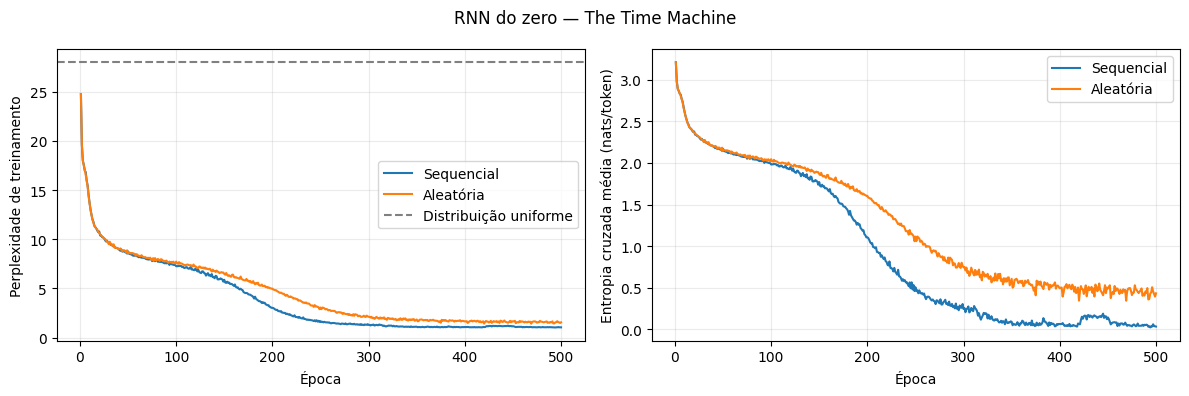

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, history in [("Sequencial", history_seq), ("Aleatória", history_random)]:
    if not history:
        continue
    epochs = [item["epoch"] for item in history]
    axes[0].plot(epochs, [item["perplexity"] for item in history], label=label)
    axes[1].plot(epochs, [item["loss"] for item in history], label=label)

axes[0].axhline(len(vocab), linestyle="--", color="gray", label="Distribuição uniforme")
axes[0].set_ylabel("Perplexidade de treinamento")
axes[1].set_ylabel("Entropia cruzada média (nats/token)")
for ax in axes:
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("RNN do zero — The Time Machine")
fig.tight_layout()
plt.show()


In [30]:
for label, model, history in [
    ("Sequencial", net_seq, history_seq),
    ("Aleatória", net_random, history_random),
]:
    if model is None:
        continue
    print(f"\n{label} | perplexidade final de treino: {history[-1]['perplexity']:.3f}")
    for prefix in ("time traveller ", "traveller ", "the time machine "):
        print(predict(prefix, 50, model, vocab))



Sequencial | perplexidade final de treino: 1.034
time traveller for so it will be convenient to speak of himwas ex
traveller with a slight accession ofcheerfulness really this
the time machine by h g wellsithe time traveller for so it will be 

Aleatória | perplexidade final de treino: 1.541
time traveller with a slight accession ofcheerfulness really this
traveller came back andfilby s anecdote collapsedthe thing t
the time machine by r ghongbage there war same be we cranot eascout


## 10. Experimentos sugeridos

1. Mude `PERFIL` para `livro` e compare as curvas e as continuações de texto.
2. Altere `num_steps` para 10 ou 70 e observe custo e qualidade.
3. Experimente `clip_theta` igual a 0,5 ou 5 e examine `max_grad_norm` no histórico
   (essa métrica registra a maior norma **antes** do recorte em cada época).
4. Para estudar generalização, separe um trecho contínuo para validação antes
   de criar os iteradores e avalie-o sem atualizar os pesos.

Um modelo pode memorizar os 10.000 caracteres usados. Uma perplexidade de treino
próxima de 1 não comprova compreensão de linguagem nem desempenho em dados novos.
A semente ajuda a repetir o experimento no mesmo ambiente; resultados entre
dispositivos e versões não precisam ser idênticos.
